In [1]:
%load_ext autoreload 
#hopefully this will reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

Plot distribution of m200
Save the plot data points in txt
Check what's wrong with bootstrap

In [2]:
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis
from myproject.listRedshiftGalaxys import ListRedshiftGalaxy
from myproject.utilities.snapshotEnum import SnapshotEnum

In [3]:
allSnapshotEnums = SnapshotEnum.getAllSnapshots()
# allSnapshots = [snapshotEnum[0] for snapshotEnum in allSnapshotEnums]

#get rid of snapshots < 50:
allSnapshotEnums = [snapshotEnum for snapshotEnum in allSnapshotEnums if snapshotEnum[0] >= 50]
allSnapshots = [snapshotEnum[0] for snapshotEnum in allSnapshotEnums]
print(allSnapshots)

[99, 91, 84, 78, 72, 67, 59, 50]


In [4]:
mass_bin_labels = [
    '$1e13<M_{200}<1e13.5$',
    '$1e13.5<M_{200}<1e14$',
    '$1e14<M_{200}<1e14.5$',
    '$1e14.5<M_{200}<1e15$',
    '$M_{200}>1e15$',
]

In [5]:
listRedshiftGalaxyAnalysis = ListRedshiftGalaxy()
listRedshiftGalaxyAnalysis.initializeAllGalaxyAnalysis(snapshot_enums=allSnapshots, simulation='TNG-Cluster', luminosityType='Default', generalErrorbar='poisson', generalRewrite=True)
# galaxyAnalysisZ0 = GalaxyAnalysis(generalRewrite=True)

Progress: 352/352
Loaded 352 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
Progress: 352/352ing Galaxy Group ID 352 / 352
Loaded 352 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p1/data/galaxy_data_TNG-Cluster_.hdf5
Progress: 352/352ing Galaxy Group ID 352 / 352
Loaded 352 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p2/data/galaxy_data_TNG-Cluster_.hdf5
Progress: 360/360ing Galaxy Group ID 352 / 352
Loaded 360 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p3/data/galaxy_data_TNG-Cluster_.hdf5
Progress: 366/366ing Galaxy Group ID 360 / 360
Loaded 366 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p4/data/galaxy_data_TNG-Cluster_.hdf5
Progress: 370/370ing Galaxy Group ID 366 / 366
Loaded 370 galaxy groups from HDF5.
Loaded gala

In [6]:
#print num of clusters and satellites in each snapshot and mass bin:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup


for snapshotEnum in allSnapshotEnums:
    snapshot = snapshotEnum[0]
    print(f"Snapshot: {snapshot}")
    galaxyAnalysis = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot)
    mass_bins : list[ListGalaxyGroup] = [
        galaxyAnalysis.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt15_list_of_galaxy_groups,
    ]
    for mass_bin, mass_bin_label in zip(mass_bins, mass_bin_labels):
        num_clusters = len(mass_bin.getAllGalaxyGroups())
        num_satellites = sum([len(galaxy_group.getSatelliteSubhalos()) for galaxy_group in mass_bin.getAllGalaxyGroups()])
        print(f" Mass bin: {mass_bin_label}, Num clusters: {num_clusters}, Num satellites: {num_satellites}")

Snapshot: 99
 Mass bin: $1e13<M_{200}<1e13.5$, Num clusters: 0, Num satellites: 0
 Mass bin: $1e13.5<M_{200}<1e14$, Num clusters: 0, Num satellites: 0
 Mass bin: $1e14<M_{200}<1e14.5$, Num clusters: 53, Num satellites: 4955
 Mass bin: $1e14.5<M_{200}<1e15$, Num clusters: 204, Num satellites: 44988
 Mass bin: $M_{200}>1e15$, Num clusters: 95, Num satellites: 46334
Snapshot: 91
 Mass bin: $1e13<M_{200}<1e13.5$, Num clusters: 0, Num satellites: 0
 Mass bin: $1e13.5<M_{200}<1e14$, Num clusters: 0, Num satellites: 0
 Mass bin: $1e14<M_{200}<1e14.5$, Num clusters: 95, Num satellites: 9807
 Mass bin: $1e14.5<M_{200}<1e15$, Num clusters: 208, Num satellites: 53054
 Mass bin: $M_{200}>1e15$, Num clusters: 49, Num satellites: 26650
Snapshot: 84
 Mass bin: $1e13<M_{200}<1e13.5$, Num clusters: 0, Num satellites: 0
 Mass bin: $1e13.5<M_{200}<1e14$, Num clusters: 6, Num satellites: 233
 Mass bin: $1e14<M_{200}<1e14.5$, Num clusters: 123, Num satellites: 13177
 Mass bin: $1e14.5<M_{200}<1e15$, Num cl

In [9]:
import numpy as np
#for snapshot 99, check how many subhalos have non nan joining redshifts compared to nan joining redshifts:
galaxyAnalysis = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
loaded_list_of_galaxy = galaxyAnalysis.loaded_list_of_galaxy_groups
# loaded_list_of_galaxy = galaxyAnalysis.filtered_gt14_list_of_galaxy_groups
num_subhalos = np.sum([len(galaxy_group.getSatelliteSubhalos()) for galaxy_group in loaded_list_of_galaxy.getAllGalaxyGroups()])
num_subhalos_nan_joining_redshifts = 0
num_subhalos_non_nan_joining_redshifts = 0
for galaxy_group in loaded_list_of_galaxy.getAllGalaxyGroups():
    for satellite_subhalo in galaxy_group.getSatelliteSubhalos():
        if np.isnan(satellite_subhalo.getJoiningRedshift()):
            num_subhalos_nan_joining_redshifts += 1
            # print(satellite_subhalo.getJoiningRedshift())
        else:
            num_subhalos_non_nan_joining_redshifts += 1
print(f"Snapshot 99: Num subhalos: {num_subhalos}, Num subhalos with nan joining redshifts: {num_subhalos_nan_joining_redshifts}, Num subhalos with non-nan joining redshifts: {num_subhalos_non_nan_joining_redshifts}")
print(f"Snapshot 99: Fraction of subhalos with nan joining redshifts: {num_subhalos_nan_joining_redshifts/num_subhalos}, Fraction of subhalos with non-nan joining redshifts: {num_subhalos_non_nan_joining_redshifts/num_subhalos}")

Snapshot 99: Num subhalos: 96277, Num subhalos with nan joining redshifts: 1756, Num subhalos with non-nan joining redshifts: 94521
Snapshot 99: Fraction of subhalos with nan joining redshifts: 0.018239039438287443, Fraction of subhalos with non-nan joining redshifts: 0.9817609605617126


In [7]:
#check in snapshot 0, that all galaxies in the gt13 ls13p5 mass bin have M200 between 1e13 and 1e13.5:
snapshotEnum = SnapshotEnum.SNAPSHOT_99
snapshot = snapshotEnum.value[0]
print(f"Snapshot: {snapshot}")
galaxyAnalysis = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot)
mass_bin = galaxyAnalysis.filtered_gt13_ls13p5_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 1e13 and M200 < 10**13.5, f"Galaxy group with M200={M200:.2e} is not in the gt13 ls13p5 mass bin!"
    
mass_bin = galaxyAnalysis.filtered_gt13p5_ls14_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 10**13.5 and M200 < 10**14, f"Galaxy group with M200={M200:.2e} is not in the gt13p5 ls14 mass bin!"
    
mass_bin = galaxyAnalysis.filtered_gt14_ls14p5_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 10**14 and M200 < 10**14.5, f"Galaxy group with M200={M200:.2e} is not in the gt14 ls14p5 mass bin!"
    
mass_bin = galaxyAnalysis.filtered_gt14p5_ls15_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 10**14.5 and M200 < 10**15, f"Galaxy group with M200={M200:.2e} is not in the gt14p5 ls15 mass bin!"
    
mass_bin = galaxyAnalysis.filtered_gt15_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 10**15, f"Galaxy group with M200={M200:.2e} is not in the gt15 mass bin!"

Snapshot: 99


# check snaphot compared to z=0

In [3]:
# galaxyAnalysisZ0 = GalaxyAnalysis(generalRewrite=True, sim='TNG-Cluster',luminosityType='Default')


Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [16]:
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    # redshifts.append(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][1])
    galaxyAnalysisSnapshot.computeAllPlots()

In [ ]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
# print(f"Number of subhalos in GG 912: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(912).getNumSubhalos()}")
rangeSat, allNumSat = galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getRangeOfNumSubhalos()
print(f' Range of satellites: {rangeSat}')
print(f' numer of sat == 1: {len(np.where(np.array(allNumSat) < 5)[0])}')

In [17]:
#from galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, save in a txt file
#save all galaxy groups with id, numSat, sum of flags for all satellites, mass, central mass, central flag, central r band, first satellite mass, first satellite flag, first satellite r band
with open('tng_cluster_galaxy_groups_info.txt', 'w') as f:
    f.write('id \t,numSat \t,sumFlags \t,mass \t,centralMass \t,centralFlag \t,centralRband \t,firstSatMass \t,firstSatFlag \t,firstSatRband \n')
    for i in range(galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()):
        gg = galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(i)
        id = gg.getGroupID()
        numSat = len(gg.getSatelliteSubhalos())
        sumFlags = np.sum([int(subhalo.getFlag()) for subhalo in gg.getSatelliteSubhalos()])
        mass = f'{gg.getMCrit200():.2e}'
        centralMass = f'{gg.getCentralSubhalo().getStellarMass():.2e}'
        centralFlag = gg.getCentralSubhalo().getFlag()
        centralRband = f'{gg.getCentralSubhalo().getDefaultRbandMagnitude():.2}'
        firstSatMass = f'{gg.getSatelliteSubhalos()[0].getStellarMass():.2e}'
        firstSatFlag = gg.getSatelliteSubhalos()[0].getFlag()
        firstSatRband = f'{gg.getSatelliteSubhalos()[0].getDefaultRbandMagnitude():.2}'
        f.write(f'{id} \t,{numSat} \t,{sumFlags} \t,{mass} \t,{centralMass} \t,{centralFlag} \t,{centralRband} \t,{firstSatMass} \t,{firstSatFlag} \t,{firstSatRband} \n')

In [ ]:
galaxyAnalysisZ0.computeAllPlots()

In [16]:
galaxyAnalysisZ0.setSnapshot(99, newsim='TNG-Cluster', luminosityType='Default')

Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [ ]:

galaxyAnalysisZ0.MRLDistributionPlots()

In [ ]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    if snapshot[0] > 70:
        continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
    galaxyAnalysisZ0.computeAllPlots()
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()

In [4]:
galaxyAnalysisZ0TNG300 = GalaxyAnalysis(generalRewrite=True, sim='TNG300-1',luminosityType='SDSS')

Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


In [15]:
print(galaxyAnalysisZ0.sim)

TNG300-1


Processing snapshot 99...
Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=z0p0, TNG-Cluster
Total Galaxy Groups to process: 913 with pairs : 18000496
Processing Subhalo 14/14 in Galaxy Group ID 4254241 with total pairs 91103841COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=0.0, TNG300-1
Total Galaxy Groups to process: 280 with pairs : 1753902
Processing Subhalo 7/550 in Galaxy Group ID 0 with total pairs 150975

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/plots/pairwise_polar_difference_cluster_vs_tng300z0_TNG-Cluster


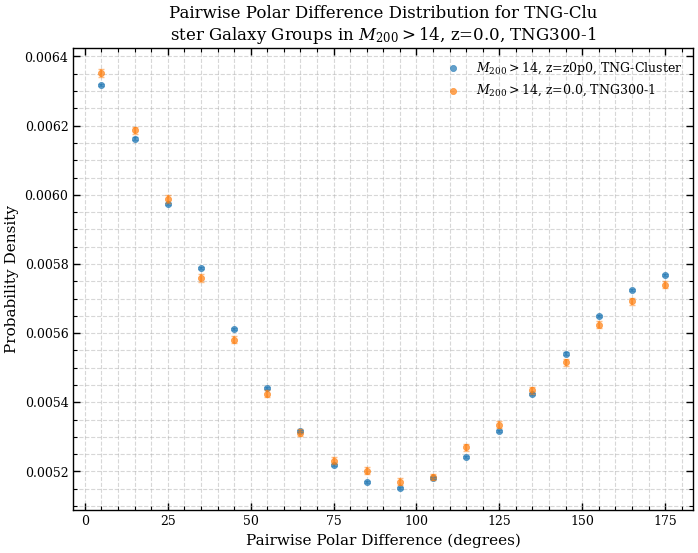

In [18]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] != 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    listRedshiftGG = []
    galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
    groupList = []
    groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG-Cluster'))
    groupList.append((galaxyAnalysisZ0TNG300.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG300-1'))
    listRedshiftGG.append(groupList)

    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, mrlOrPolar='polar', oneaxis=True)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right')  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_cluster_vs_tng300z0_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

In [5]:
# make a plot of the number of galaxies per unit volume, per unit r-band magnitude.  That’s the luminosity function
L=205*1e3
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
import numpy as np
import matplotlib.pyplot as plt
def plot_luminosity_function(list_gg:ListGalaxyGroup, plot_dirc:str='', label=None,
                             color=None, hist_kwargs=None, ax=None):
    rmags = []
    for gg in list_gg.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmags.append(galaxy.getRbandMagnitude()) if label=='SDSS' else rmags.append(galaxy.getDefaultRbandMagnitude())
    
    bins ='auto'
    xlow=-23
    xhigh=-7
    bins = np.linspace(xlow, xhigh, 100)
    volume =L**3
    print(f"unit volume used: {volume}")
    # print(f"rmags: {rmags}")
    
    mags = np.asarray(rmags)
    hist, edges = np.histogram(mags, bins=bins)
    width = np.diff(edges)
    values = hist.astype(float) / width
    if volume is not None:
        values = values / float(volume)
    centers = edges[:-1] + 0.5 * width
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    hk = {} if hist_kwargs is None else dict(hist_kwargs)
    ax.step(centers, values, where='mid', label=label, color=color, **hk)
    ax.set_xlabel('r-band magnitude')
    ylabel = 'Number / mag / L^3'
    title = 'Luminosity Function'
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right')
    ax.set_title(title)
    ax.invert_xaxis()
    ax.set_xlim(xlow, xhigh)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    return centers, values

unit volume used: 8615125000000000.0


(array([-22.91919192, -22.75757576, -22.5959596 , -22.43434343,
        -22.27272727, -22.11111111, -21.94949495, -21.78787879,
        -21.62626263, -21.46464646, -21.3030303 , -21.14141414,
        -20.97979798, -20.81818182, -20.65656566, -20.49494949,
        -20.33333333, -20.17171717, -20.01010101, -19.84848485,
        -19.68686869, -19.52525253, -19.36363636, -19.2020202 ,
        -19.04040404, -18.87878788, -18.71717172, -18.55555556,
        -18.39393939, -18.23232323, -18.07070707, -17.90909091,
        -17.74747475, -17.58585859, -17.42424242, -17.26262626,
        -17.1010101 , -16.93939394, -16.77777778, -16.61616162,
        -16.45454545, -16.29292929, -16.13131313, -15.96969697,
        -15.80808081, -15.64646465, -15.48484848, -15.32323232,
        -15.16161616, -15.        , -14.83838384, -14.67676768,
        -14.51515152, -14.35353535, -14.19191919, -14.03030303,
        -13.86868687, -13.70707071, -13.54545455, -13.38383838,
        -13.22222222, -13.06060606, -12.

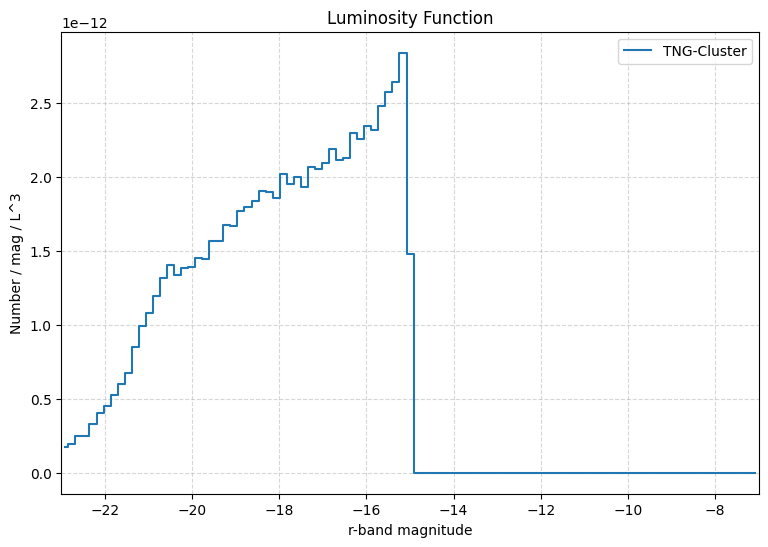

In [7]:
figSDSS, axSDSS = plt.subplots(figsize=(9,6))
plot_luminosity_function(galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, ax=axSDSS, label='TNG-Cluster')


In [9]:
%pwd

'/home/poulin.al/git/sat-lopsidedness/src/myproject'

In [10]:
#given a txt file that looks like:
# '''
# # # TNG-Cluster Catalog (see: https://www.tng-project.org/data/cluster/ and http://arxiv.org/abs/2311.06338)
# # Note: this table is dynamic, and new columns are frequently added. Requests for additions are welcome.
# # If you use quantities from this table, please also cite the relevant paper, when indicated for a column.
# # [352] halos, all properties at [z=0] unless specified otherwise.
# #
# # columns: 
# # [1] origID: Original Parent Halo ID (for reference only)
# # [2] haloID: TNG-Cluster Halo ID (in the group catalog)
# # [3] mhalo_200c: Halo mass within r200c [log M$_\odot$]
# # [4] mhalo_500c: Halo mass within r500c [log M$_\odot$]
# # [5] r200c: Halo radius r200c [Mpc]
# #
#    0        0 15.29 15.13 2.629 1.711 12.58 12.76 11.74 10.51 0.145   nan 45.28 -3.69  34.05 -0.79  8.11 0.49 854 502 248  62  CC  0.45  39.57  -0.93  1.69 0.14 0.64 0  0.23  0.67  0.55  0.60  0.45  0.72 
#    1   252455 15.40 15.27 2.871 1.912 12.16 12.49 11.37  9.35 0.126   nan 44.96 -3.48  11.91 -2.16  8.36 0.38 708 423 202  63 NCC 12.96 566.18  -2.20  0.19 0.01 0.12 0  1.91  2.81  1.84  1.35  1.75  1.93 
#    2   476245 15.16 14.99 2.378 1.541 12.16 12.40 11.82 10.17 0.132   nan 44.59 -3.94   3.61 -2.35  8.17 0.39 718 427 210  68 NCC 16.48 515.67  -2.41  0.19 0.01 0.10 0  1.41  2.29  2.23  1.04  1.26  1.63 
#    3   692426 15.36 15.14 2.782 1.731 12.53 12.72 11.55 10.19 0.149   nan 45.06 -3.61   9.16 -1.33  7.95 0.08 628 363 167  49 WCC  1.13  57.04  -1.44  0.81 0.07 0.26 0  1.02  0.46  0.93  2.68  2.72  2.84 
# '''
   
#read the id's
primary_halo_ids = []
with open('tng-cluster-primaryinfo.txt', 'r') as file:
    lines = file.readlines()
    for line in lines:
        print(line)
        if line.startswith('#') or line.strip() == '':
            continue  # Skip header or empty lines
        parts = line.split()
        if len(parts) > 1:
            primary_halo_ids.append(int(parts[1]))  # Assuming haloID is the second column
        

# TNG-Cluster Catalog (see: https://www.tng-project.org/data/cluster/ and http://arxiv.org/abs/2311.06338)

# Note: this table is dynamic, and new columns are frequently added. Requests for additions are welcome.

# If you use quantities from this table, please also cite the relevant paper, when indicated for a column.

# [352] halos, all properties at [z=0] unless specified otherwise.

#

# columns: 

# [1] origID: Original Parent Halo ID (for reference only)

# [2] haloID: TNG-Cluster Halo ID (in the group catalog)

# [3] mhalo_200c: Halo mass within r200c [log M$_\odot$]

# [4] mhalo_500c: Halo mass within r500c [log M$_\odot$]

# [5] r200c: Halo radius r200c [Mpc]

# [6] r500c: Halo radius r500c [Mpc]

# [7] mstar_30kpc: Stellar mass within 30 kpc [log(M$_\star$ / M$_\odot$]

# [8] mstar_100kpc: Stellar mass within 100 kpc [log(M$_\star$ / M$_\odot$]

# [9] mhi_halo: Neutral HI mass within the (FoF) halo [log M$_\odot$]

# [10] mass_smbh: Mass of central SMBH [log M$_\odot$]

# [11

In [24]:
galaxyAnalysisZ0PrimaryOnly = GalaxyAnalysis(generalRewrite=True, sim='TNG-Cluster',luminosityType='Default')

Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [25]:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
#now filter to only the primary halo ids that are in our galaxy groups
filtered_primary_gt14_list_of_galaxy_groups = []
for gg in galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    if gg.getGroupID() in primary_halo_ids:
        print(f"Galaxy group with primary halo ID {gg.getGroupID()} is in the TNG-Cluster catalog.")
        filtered_primary_gt14_list_of_galaxy_groups.append(gg)
        
galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups = ListGalaxyGroup(filtered_primary_gt14_list_of_galaxy_groups, headerInformation=galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getHeaderInformation())        

Galaxy group with primary halo ID 0 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4356618 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4461296 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4561713 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4656216 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4753637 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 476245 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4854863 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4959833 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5059214 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5160063 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5251697 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5348819 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5432141 is in the TNG-Cl

In [28]:
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')


Number of galaxy groups loaded: 352
Number of galaxy groups loaded: 352


COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=z0p0, TNG-Cluster
Total Galaxy Groups to process: 352 with pairs : 17732249
Processing Subhalo 639/639 in Galaxy Group ID 4254230 with total pairs 203841COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=0.0, TNG-Cluster only primaries
Total Galaxy Groups to process: 352 with pairs : 17732249
Processing Subhalo 6/626 in Galaxy Group ID 0 with total pairs 195625

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 639/639 in Galaxy Group ID 4254230 with total pairs 203841Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/plots/pairwise_polar_difference_cluster_vs_cluster-primaries_TNG-Cluster


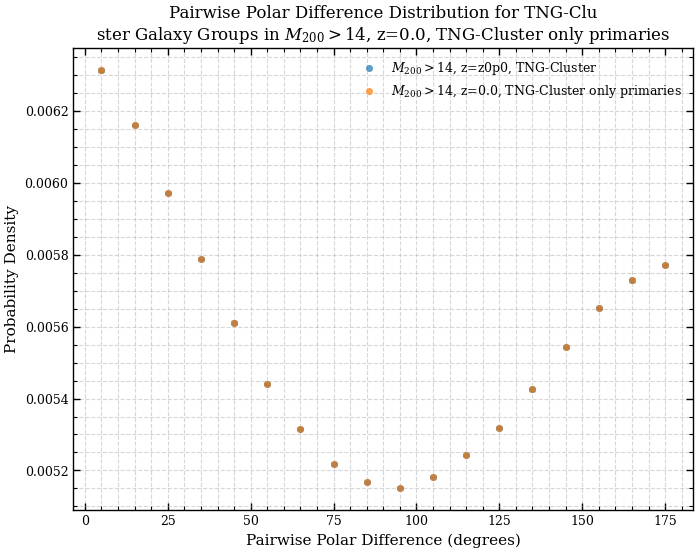

In [27]:
listRedshiftGG = []
# galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
snapshot=(99,)
groupList = []
groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG-Cluster'))
groupList.append((galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG-Cluster only primaries'))
listRedshiftGG.append(groupList)

polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, typePlot='polar', oneaxis=True)#, plotRows=2, plotCols=3)
# galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
polar_ax.legend(loc='upper right')  # Add legend to the last subplot
polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_cluster_vs_cluster-primaries_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

# overall change dependence

In [6]:
# get the percent of clusters below the 99% / 95% / 90% CL of random MRL, and plot it across redshift
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

redshifts = []
fracBelow99 = []
fracBelow95 = []
fracBelow90 = []

errBelow99 = []
errBelow95 = []
errBelow90 = []


def binomial_sigma(p, n):
    p = float(p)
    n = int(n)
    if n <= 0:
        return 0.0
    return float(np.sqrt(p * (1.0 - p) / n))


for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    redshifts.append(snapshot[1])

    # Note: getPercentOfClustersAboveRandomMRLCL returns the fraction/count/total *below* the percentile.
    (f99, c99, n99, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=99
    )
    (f95, c95, n95, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=95
    )
    (f90, c90, n90, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=90
    )

    fracBelow99.append(f99)
    fracBelow95.append(f95)
    fracBelow90.append(f90)

    errBelow99.append(binomial_sigma(f99, n99))
    errBelow95.append(binomial_sigma(f95, n95))
    errBelow90.append(binomial_sigma(f90, n90))

Processing snapshot 99...
final: [np.float64(0.06258291970169315), np.float64(0.08903413663791833), np.float64(0.0892243707794891)]
Fraction of MRL values below the 99th percentile of random MRL values: 0.6383 (674/1056)tes
final: [np.float64(0.06258291970169315), np.float64(0.08903413663791833), np.float64(0.0892243707794891)]
Fraction of MRL values below the 95th percentile of random MRL values: 0.5114 (540/1056)tes
final: [np.float64(0.06258291970169315), np.float64(0.08903413663791833), np.float64(0.0892243707794891)]
Fraction of MRL values below the 90th percentile of random MRL values: 0.4261 (450/1056)tes
Processing snapshot 91...
final: [np.float64(0.04457546409561305), np.float64(0.11148411266146875), np.float64(0.13464093389144446)]
Fraction of MRL values below the 99th percentile of random MRL values: 0.6439 (680/1056)tes
final: [np.float64(0.04457546409561305), np.float64(0.11148411266146875), np.float64(0.13464093389144446)]
Fraction of MRL values below the 95th percentile

Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z1p0/plots/percent_clusters_above_random_MRL_CL_vs_redshift_TNG-Cluster


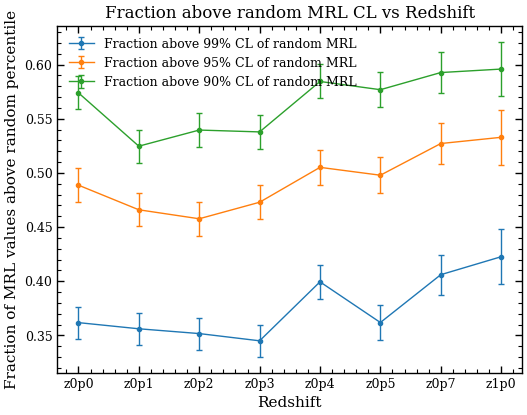

In [7]:
MRL_CL_plotter = AstroPlotter()
MRL_CL_fig, MRL_CL_ax = MRL_CL_plotter.create_figure()

MRL_CL_ax.errorbar(
    redshifts,
    1-np.array(fracBelow99),
    yerr=errBelow99,
    label='Fraction above 99% CL of random MRL',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
MRL_CL_ax.errorbar(
    redshifts,
    1-np.array(fracBelow95),
    yerr=errBelow95,
    label='Fraction above 95% CL of random MRL',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
MRL_CL_ax.errorbar(
    redshifts,
    1-np.array(fracBelow90),
    yerr=errBelow90,
    label='Fraction above 90% CL of random MRL',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)

MRL_CL_ax.set_xlabel('Redshift')
MRL_CL_ax.set_ylabel('Fraction of MRL values above random percentile')
MRL_CL_ax.set_title('Fraction above random MRL CL vs Redshift')
MRL_CL_ax.legend(loc='upper left')

MRL_CL_plotter.save_figure(
    MRL_CL_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/percent_clusters_above_random_MRL_CL_vs_redshift_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

In [9]:
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
random_MRL_values = galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(
            parallelize=False, num_samples=1000
        )
print(f"num galaxies in gt13 lt13p5: {galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups.getNumGalaxyGroups()}")
(f99, c99, n99, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups, percentageMRL=90, random_mrl_values=random_MRL_values
        )
print(f99, c99, n99)


num galaxies in gt13 lt13p5: 0
Fraction of MRL values below the 90th percentile of random MRL values: 0.0000 (0/0)
0 0 0


In [10]:
# do the same but for the 5 mass groups
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

redshifts = []

mass_bin_labels = [
    '$1e13<M_{200}<1e13.5$',
    '$1e13.5<M_{200}<1e14$',
    '$1e14<M_{200}<1e14.5$',
    '$1e14.5<M_{200}<1e15$',
    '$M_{200}>1e15$',
]

fracBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
fracBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
fracBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]

errBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
errBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
errBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]


def binomial_sigma(p, n):
    p = float(p)
    n = int(n)
    if n <= 0:
        return 0.0
    return float(np.sqrt(p * (1.0 - p) / n))


for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    

    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]

    redshifts.append(snapshot[1])

    for i, mass_bin in enumerate(mass_bins):
        random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(
            parallelize=False, num_samples=1000
        )

        (f99, c99, n99, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=99, random_mrl_values=random_MRL_values
        )
        (f95, c95, n95, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=95, random_mrl_values=random_MRL_values
        )
        (f90, c90, n90, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=90, random_mrl_values=random_MRL_values
        )

        fracBelow99_mass_bins[i].append(f99)
        fracBelow95_mass_bins[i].append(f95)
        fracBelow90_mass_bins[i].append(f90)

        errBelow99_mass_bins[i].append(binomial_sigma(f99, n99))
        errBelow95_mass_bins[i].append(binomial_sigma(f95, n95))
        errBelow90_mass_bins[i].append(binomial_sigma(f90, n90))

Processing snapshot 99...
Fraction of MRL values below the 99th percentile of random MRL values: 0.0000 (0/0)
Fraction of MRL values below the 95th percentile of random MRL values: 0.0000 (0/0)
Fraction of MRL values below the 90th percentile of random MRL values: 0.0000 (0/0)
Fraction of MRL values below the 99th percentile of random MRL values: 0.0000 (0/0)
Fraction of MRL values below the 95th percentile of random MRL values: 0.0000 (0/0)
Fraction of MRL values below the 90th percentile of random MRL values: 0.0000 (0/0)


Fraction of MRL values below the 99th percentile of random MRL values: 0.8033 (294/366)ites
Fraction of MRL values below the 95th percentile of random MRL values: 0.6585 (241/366)
Fraction of MRL values below the 90th percentile of random MRL values: 0.5683 (208/366)
Fraction of MRL values below the 99th percentile of random MRL values: 0.6123 (248/405)ites
Fraction of MRL values below the 95th percentile of random MRL values: 0.4741 (192/405)
Fraction of MRL values below the 90th percentile of random MRL values: 0.4049 (164/405)
final: [np.float64(0.06258291970169315), np.float64(0.08903413663791833), np.float64(0.0892243707794891)]
Fraction of MRL values below the 99th percentile of random MRL values: 0.4702 (134/285)
final: [np.float64(0.06258291970169315), np.float64(0.08903413663791833), np.float64(0.0892243707794891)]
Fraction of MRL values below the 95th percentile of random MRL values: 0.3789 (108/285)
final: [np.float64(0.06258291970169315), np.float64(0.08903413663791833), np

In [11]:
# mask = np.nonzero(fracBelow99_mass_bins[0])[0]
print(fracBelow99_mass_bins[0])
mask = np.array(fracBelow99_mass_bins[0]) != 0
print(np.array(fracBelow99_mass_bins[0])[mask])
print(np.array(redshifts)[mask])

[0, 0, 0, np.float64(1.0), np.float64(0.9166666666666666), np.float64(0.9285714285714286), np.float64(0.8529411764705882), np.float64(0.7615384615384615)]
[1.         0.91666667 0.92857143 0.85294118 0.76153846]
['z0p3' 'z0p4' 'z0p5' 'z0p7' 'z1p0']


Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z1p0/plots/percent_clusters_above_random_MRL_CL_vs_redshift_for_mass_bins_TNG-Cluster


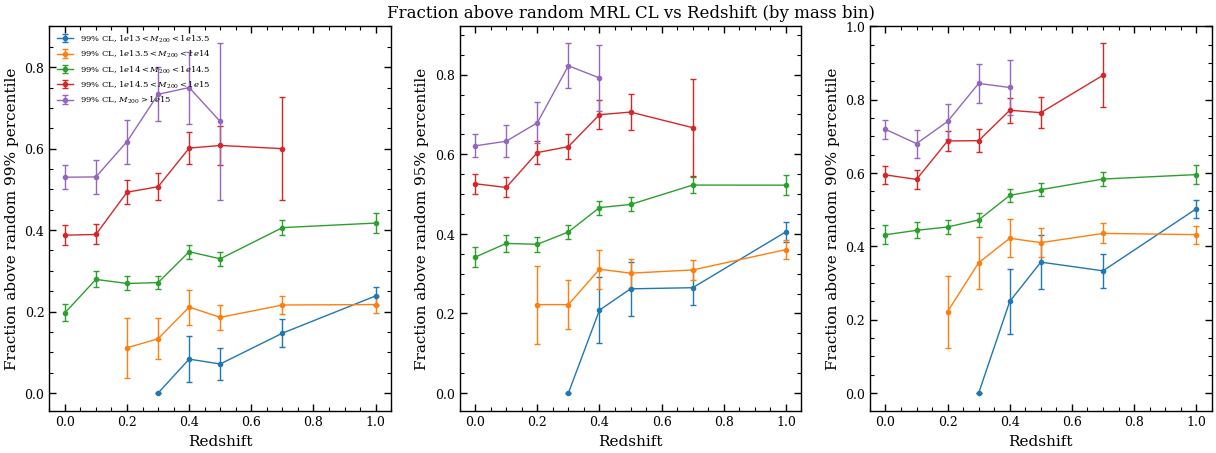

In [12]:
mass_bin_MRL_CL_plotter = AstroPlotter()
mass_bin_MRL_CL_fig, mass_bin_MRL_CL_ax = mass_bin_MRL_CL_plotter.create_figure(
    nrows=1,
    ncols=3,
    figsize=(15, 5),
)  # each col is a different confidence level, each line is a different mass bin

redshifts = SnapshotEnum.getAllRedshifts()[:8]


for i in range(len(mass_bin_labels)):
    # 99% CL — select non-zero entries and sort by redshift before plotting
    y99 = np.array(fracBelow99_mass_bins[i], dtype=float)
    mask99 = y99 != 0
    if np.any(mask99):
        x99 = np.array(redshifts)[mask99]
        y99_sel = 1.0 - y99[mask99]
        yerr99 = np.array(errBelow99_mass_bins[i])[mask99]
        order99 = np.argsort(x99)
        mass_bin_MRL_CL_ax[0].errorbar(
            x99[order99],
            y99_sel[order99],
            yerr=yerr99[order99],
            label=f'99% CL, {mass_bin_labels[i]}',
            marker='o',
            linestyle='-',
            capsize=2,
            elinewidth=1,
            linewidth=1,
            markersize=3,
        )

    # 95% CL
    y95 = np.array(fracBelow95_mass_bins[i], dtype=float)
    mask95 = y95 != 0
    if np.any(mask95):
        x95 = np.array(redshifts)[mask95]
        y95_sel = 1.0 - y95[mask95]
        yerr95 = np.array(errBelow95_mass_bins[i])[mask95]
        order95 = np.argsort(x95)
        mass_bin_MRL_CL_ax[1].errorbar(
            x95[order95],
            y95_sel[order95],
            yerr=yerr95[order95],
            label=f'95% CL, {mass_bin_labels[i]}',
            marker='o',
            linestyle='-',
            capsize=2,
            elinewidth=1,
            linewidth=1,
            markersize=3,
        )

    # 90% CL
    y90 = np.array(fracBelow90_mass_bins[i], dtype=float)
    mask90 = y90 != 0
    if np.any(mask90):
        x90 = np.array(redshifts)[mask90]
        y90_sel = 1.0 - y90[mask90]
        yerr90 = np.array(errBelow90_mass_bins[i])[mask90]
        order90 = np.argsort(x90)
        mass_bin_MRL_CL_ax[2].errorbar(
            x90[order90],
            y90_sel[order90],
            yerr=yerr90[order90],
            label=f'90% CL, {mass_bin_labels[i]}',
            marker='o',
            linestyle='-',
            capsize=2,
            elinewidth=1,
            linewidth=1,
            markersize=3,
        )

mass_bin_MRL_CL_ax[0].set_xlabel('Redshift')
mass_bin_MRL_CL_ax[1].set_xlabel('Redshift')
mass_bin_MRL_CL_ax[2].set_xlabel('Redshift')

mass_bin_MRL_CL_ax[0].set_ylabel('Fraction above random 99% percentile')
mass_bin_MRL_CL_ax[1].set_ylabel('Fraction above random 95% percentile')
mass_bin_MRL_CL_ax[2].set_ylabel('Fraction above random 90% percentile')

mass_bin_MRL_CL_ax[1].set_title('Fraction above random MRL CL vs Redshift (by mass bin)')

mass_bin_MRL_CL_ax[0].legend(fontsize=6, loc='upper left')

mass_bin_MRL_CL_plotter.save_figure(
    mass_bin_MRL_CL_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/percent_clusters_above_random_MRL_CL_vs_redshift_for_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

In [13]:
#take the difference of polar pairwise < 90º with polar pairwise > 90º and plot it across redshift for the full sample and for the 5 mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

def polar_lt90_ge90_stats_from_hist(angles_deg, bin_size_deg=5.0):
    """
    Compute counts and fractions using a (normalized) histogram with an edge at 90°.

    Returns a dict with:
      - total
      - n_lt90, n_ge90 (expected counts from histogram; equals counts for equal weights)
      - frac_lt90, frac_ge90 (fractions; sum to 1 when total>0)
      - diff = n_lt90 - n_ge90
      - sigma_poisson = sqrt(n_lt90 + n_ge90)
    """
    angles = np.asarray(angles_deg, dtype=float)
    if angles.size == 0:
        return {
            'total': 0,
            'n_lt90': 0.0,
            'n_ge90': 0.0,
            'frac_lt90': 0.0,
            'frac_ge90': 0.0,
            'diff': 0.0,
            'sigma_poisson': 0.0,
        }
    bins = np.arange(0.0, 180.0 + bin_size_deg, bin_size_deg)
    counts, edges = np.histogram(angles, bins=bins)
    total = int(counts.sum())
    if total == 0:
        return {
            'total': 0,
            'n_lt90': 0.0,
            'n_ge90': 0.0,
            'frac_lt90': 0.0,
            'frac_ge90': 0.0,
            'diff': 0.0,
            'sigma_poisson': 0.0,
        }
    # normalized histogram (probability mass per bin)
    prob = counts / total
    lt_mask = edges[:-1] < 90.0  # bins with left edge < 90° are counted as <90° (e.g. [85,90))
    frac_lt90 = float(prob[lt_mask].sum())
    frac_ge90 = float(prob[~lt_mask].sum())
    # expected counts from normalized histogram
    n_lt90 = frac_lt90 * total
    n_ge90 = frac_ge90 * total
    diff = n_lt90 - n_ge90
    sigma_poisson = float(np.sqrt(n_lt90 + n_ge90))
    return {
        'total': total,
        'n_lt90': float(n_lt90),
        'n_ge90': float(n_ge90),
        'frac_lt90': float(frac_lt90),
        'frac_ge90': float(frac_ge90),
        'diff': float(diff),
        'sigma_poisson': float(sigma_poisson),
    }

redshifts = []

# values used for plotting (counts-difference + poisson errors)
polarDifference_full_sample = []
polarDifference_full_sample_err = []
polarDifference_mass_bins = []
polarDifference_mass_bins_err = []

# keep both expected counts and fractions for later inspection/analysis
full_total_pairs = []
full_n_lt90 = []
full_n_ge90 = []
full_frac_lt90 = []
full_frac_ge90 = []

mass_bin_labels = ['$1e13<M_{200}<1e13.5$', '$1e13.5<M_{200}<1e14$', '$1e14<M_{200}<1e14.5$', '$1e14.5<M_{200}<1e15$', '$M_{200}>1e15$']
mass_total_pairs = [[] for _ in range(len(mass_bin_labels))]
mass_n_lt90 = [[] for _ in range(len(mass_bin_labels))]
mass_n_ge90 = [[] for _ in range(len(mass_bin_labels))]
mass_frac_lt90 = [[] for _ in range(len(mass_bin_labels))]
mass_frac_ge90 = [[] for _ in range(len(mass_bin_labels))]

polarDifference_mass_bins = [[] for _ in range(len(mass_bin_labels))]
polarDifference_mass_bins_err = [[] for _ in range(len(mass_bin_labels))]

for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    redshifts.append(snapshot[1])
    
    # Build the "full sample" by accumulating angles from the mass bins,
    # so we don't recompute the polar differences twice.
    full_angles = []
    for i, mass_bin in enumerate(mass_bins):
        polarRawValues = mass_bin.compute_probablity_distribution_of_polar_differences()
        full_angles.extend(polarRawValues)
        stats = polar_lt90_ge90_stats_from_hist(polarRawValues, bin_size_deg=5.0)
        polarDifference_mass_bins[i].append(stats['diff'])
        polarDifference_mass_bins_err[i].append(stats['sigma_poisson'])
        mass_total_pairs[i].append(stats['total'])
        mass_n_lt90[i].append(stats['n_lt90'])
        mass_n_ge90[i].append(stats['n_ge90'])
        mass_frac_lt90[i].append(stats['frac_lt90'])
        mass_frac_ge90[i].append(stats['frac_ge90'])
    
    stats_full = polar_lt90_ge90_stats_from_hist(full_angles, bin_size_deg=5.0)
    polarDifference_full_sample.append(stats_full['diff'])
    polarDifference_full_sample_err.append(stats_full['sigma_poisson'])
    full_total_pairs.append(stats_full['total'])
    full_n_lt90.append(stats_full['n_lt90'])
    full_n_ge90.append(stats_full['n_ge90'])
    full_frac_lt90.append(stats_full['frac_lt90'])
    full_frac_ge90.append(stats_full['frac_ge90'])

Processing snapshot 99...
Total Galaxy Groups to process: 0 with pairs : 0
Total Galaxy Groups to process: 0 with pairs : 0
Total Galaxy Groups to process: 122 with pairs : 991346
Processing Subhalo 8/130 in Galaxy Group ID 12981983 with total pairs 8385

Processing Subhalo 146/146 in Galaxy Group ID 5787144 with total pairs 105853Total Galaxy Groups to process: 135 with pairs : 4782578
Processing Subhalo 316/316 in Galaxy Group ID 9720881 with total pairs 497703Total Galaxy Groups to process: 95 with pairs : 11958325
Processing Subhalo 427/427 in Galaxy Group ID 9956048 with total pairs 909516Processing snapshot 91...
Total Galaxy Groups to process: 0 with pairs : 0
Total Galaxy Groups to process: 0 with pairs : 0
Total Galaxy Groups to process: 172 with pairs : 1758578
Processing Subhalo 177/177 in Galaxy Group ID 9836071 with total pairs 155761Total Galaxy Groups to process: 131 with pairs : 6295320
Processing Subhalo 321/321 in Galaxy Group ID 10060723 with total pairs 51360Total Galaxy Groups to process: 49 with pairs : 7540728
Processing Subhalo 488/488 in Galaxy Group ID 9557666 with total pairs 118828Processing snapshot 84...
Total Galaxy Groups to process: 0 with pairs : 0
Total Galaxy Groups to process: 6 with pairs : 4975
Pro

Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z1p0/plots/polar_pairwise_difference_vs_redshift_for_full_sample_and_mass_bins_TNG-Cluster


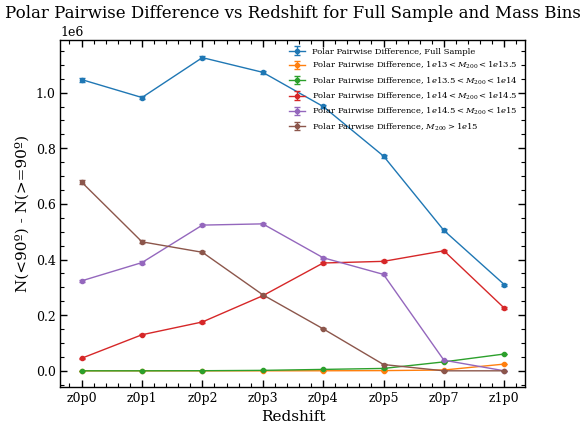

In [14]:
polarPairwiseDifference_plotter = AstroPlotter()
polarPairwiseDifference_fig, polarPairwiseDifference_ax = polarPairwiseDifference_plotter.create_figure()
polarPairwiseDifference_ax.errorbar(
    redshifts,
    polarDifference_full_sample,
    yerr=polarDifference_full_sample_err,
    label='Polar Pairwise Difference, Full Sample',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
    )
for i in range(len(mass_bin_labels)):
    polarPairwiseDifference_ax.errorbar(
        redshifts,
        polarDifference_mass_bins[i],
        yerr=polarDifference_mass_bins_err[i],
        label=f'Polar Pairwise Difference, {mass_bin_labels[i]}',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )
polarPairwiseDifference_ax.set_xlabel('Redshift')
polarPairwiseDifference_ax.set_ylabel('N(<90º) - N(>=90º)')
polarPairwiseDifference_ax.set_title('Polar Pairwise Difference vs Redshift for Full Sample and Mass Bins')
polarPairwiseDifference_ax.legend(fontsize=6)
polarPairwiseDifference_plotter.save_figure(polarPairwiseDifference_fig, galaxyAnalysisSnapshot.scratchPlotDirc + f'/polar_pairwise_difference_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')

Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z1p0/plots/polar_pairwise_difference_normalized_vs_redshift_for_full_sample_and_mass_bins_poisson_propagated_TNG-Cluster


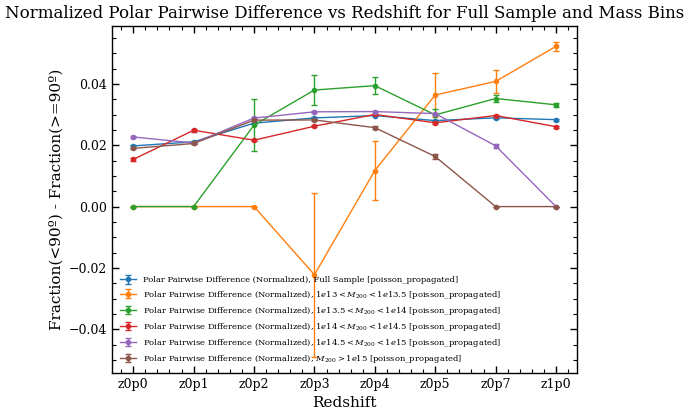

In [15]:
#take the difference of polar pairwise < 90º with polar pairwise > 90º and plot it across redshift for the full sample and for the 5 mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
# plot the normalized version of the above (frac(<90º) - frac(>=90º)) vs redshift for the full sample and mass bins
import numpy as np

# Choose error model for d = f_lt - f_ge
# - 'binomial': previous multinomial/binomial approximation
# - 'poisson_propagated': Poisson on <90 and >=90 counts, normalized by N, then propagated
error_model = 'poisson_propagated'  # set to 'binomial' to recover the previous behavior

def frac_diff_and_sigma(frac_lt, frac_ge, n_total, n_lt, n_ge, model='binomial'):
    d = float(frac_lt) - float(frac_ge)
    n = int(n_total)
    if n <= 0:
        return d, 0.0

    if model == 'binomial':
        # Previous formula: Var(d) = (1 - d^2) / N
        sigma = float(np.sqrt(max(0.0, 1.0 - d * d) / n))
        return d, sigma

    if model == 'poisson_propagated':
        # Poisson on counts, then normalize to fractions by N
        sigma_f_lt = np.sqrt(max(float(n_lt), 0.0)) / n
        sigma_f_ge = np.sqrt(max(float(n_ge), 0.0)) / n
        sigma = float(np.sqrt(sigma_f_lt**2 + sigma_f_ge**2))
        return d, sigma

    raise ValueError(f'Unknown error model: {model}')

full_frac_diff = []
full_frac_diff_err = []
for frac_lt, frac_ge, n, n_lt, n_ge in zip(full_frac_lt90, full_frac_ge90, full_total_pairs, full_n_lt90, full_n_ge90):
    d, s = frac_diff_and_sigma(frac_lt, frac_ge, n, n_lt, n_ge, model=error_model)
    full_frac_diff.append(d)
    full_frac_diff_err.append(s)

mass_frac_diff = [[] for _ in range(len(mass_bin_labels))]
mass_frac_diff_err = [[] for _ in range(len(mass_bin_labels))]
for i in range(len(mass_bin_labels)):
    for frac_lt, frac_ge, n, n_lt, n_ge in zip(
        mass_frac_lt90[i],
        mass_frac_ge90[i],
        mass_total_pairs[i],
        mass_n_lt90[i],
        mass_n_ge90[i],
    ):
        d, s = frac_diff_and_sigma(frac_lt, frac_ge, n, n_lt, n_ge, model=error_model)
        mass_frac_diff[i].append(d)
        mass_frac_diff_err[i].append(s)

polarPairwiseDifferenceNorm_plotter = AstroPlotter()
polarPairwiseDifferenceNorm_fig, polarPairwiseDifferenceNorm_ax = polarPairwiseDifferenceNorm_plotter.create_figure()

polarPairwiseDifferenceNorm_ax.errorbar(
    redshifts,
    full_frac_diff,
    yerr=full_frac_diff_err,
    label=f'Polar Pairwise Difference (Normalized), Full Sample [{error_model}]',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)

for i in range(len(mass_bin_labels)):
    polarPairwiseDifferenceNorm_ax.errorbar(
        redshifts,
        mass_frac_diff[i],
        yerr=mass_frac_diff_err[i],
        label=f'Polar Pairwise Difference (Normalized), {mass_bin_labels[i]} [{error_model}]',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )

polarPairwiseDifferenceNorm_ax.set_xlabel('Redshift')
polarPairwiseDifferenceNorm_ax.set_ylabel('Fraction(<90º) - Fraction(>=90º)')
polarPairwiseDifferenceNorm_ax.set_title('Normalized Polar Pairwise Difference vs Redshift for Full Sample and Mass Bins')
polarPairwiseDifferenceNorm_ax.legend(fontsize=6)

polarPairwiseDifferenceNorm_plotter.save_figure(
    polarPairwiseDifferenceNorm_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_normalized_vs_redshift_for_full_sample_and_mass_bins_{error_model}_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

Processing snapshot 99...
Processing snapshot 91...
Processing snapshot 84...
Processing snapshot 78...
Processing snapshot 72...
Processing snapshot 67...
Processing snapshot 59...
Processing snapshot 50...
Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z1p0/plots/median_mass_vs_redshift_for_full_sample_and_mass_bins_TNG-Cluster


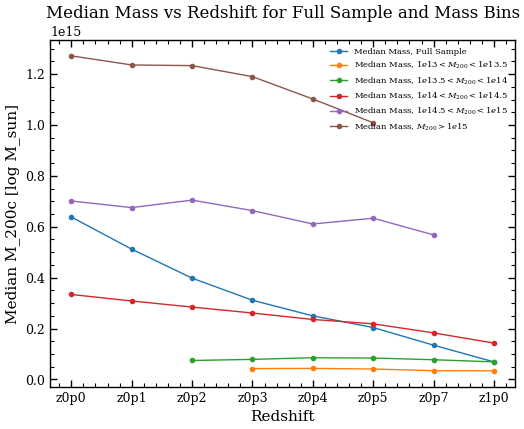

In [16]:
#see how median mass changes with redshift for the full sample and for the 5 mass bins (should be relatively flat since we are binning by mass, but good to check)
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np
redshifts = []
median_mass_full_sample = []
median_mass_mass_bins = [[] for _ in range(len(mass_bin_labels))]

for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    redshifts.append(snapshot[1])
    
    # Full sample median mass
    all_masses = []
    for mass_bin in mass_bins:
        for gg in mass_bin.getAllGalaxyGroups():
            all_masses.append(gg.getMCrit200())
    if len(all_masses) > 0:
        median_mass_full_sample.append(float(np.median(all_masses)))
    else:        
        median_mass_full_sample.append(np.nan)
    # Mass bin median masses
    for i, mass_bin in enumerate(mass_bins):
        masses = [gg.getMCrit200() for gg in mass_bin.getAllGalaxyGroups()]
        if len(masses) > 0:
            median_mass_mass_bins[i].append(float(np.median(masses)))
        else:
            median_mass_mass_bins[i].append(np.nan)
mass_bin_median_mass_plotter = AstroPlotter()
mass_bin_median_mass_fig, mass_bin_median_mass_ax = mass_bin_median_mass_plotter.create_figure()
mass_bin_median_mass_ax.plot(
    redshifts,
    median_mass_full_sample,
    label='Median Mass, Full Sample',
    marker='o',
    linestyle='-',
    linewidth=1,
    markersize=3,
)
for i in range(len(mass_bin_labels)):
    mass_bin_median_mass_ax.plot(
        redshifts,
        median_mass_mass_bins[i],
        label=f'Median Mass, {mass_bin_labels[i]}',
        marker='o',
        linestyle='-',
        linewidth=1,
        markersize=3,
    )
mass_bin_median_mass_ax.set_xlabel('Redshift')
mass_bin_median_mass_ax.set_ylabel('Median M_200c [log M_sun]')
mass_bin_median_mass_ax.set_title('Median Mass vs Redshift for Full Sample and Mass Bins')
mass_bin_median_mass_ax.legend(fontsize=6)
mass_bin_median_mass_plotter.save_figure(
    mass_bin_median_mass_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/median_mass_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)